In [3]:
%pylab inline

# import warnings;
# warnings.filterwarnings('ignore');

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
# from mpl_toolkits.mplot3d import Axes3D

from matplotlib import rc
rc('text', usetex=True)
# rc('font', family='Times New Roman', size='20')
fontsize = 22
params = {
    'font.family': 'Times New Roman',
#     'font.weight': 150,
    'font.size': fontsize,
    'axes.titlesize': fontsize,
    'axes.labelsize': fontsize ,
    'xtick.labelsize': fontsize-2,
    'ytick.labelsize': fontsize-2,
    'legend.fontsize': fontsize-5,
}
rcParams.update(params)

Duplicate key in file '/Users/chigamma/.matplotlib/matplotlibrc' line #2.

Bad key "“backend" on line 2 in
/Users/chigamma/.matplotlib/matplotlibrc.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


Populating the interactive namespace from numpy and matplotlib


In [4]:
import os
import argparse
import re

In [5]:
def geteacc(acc_lst, acc=80):
    for i, v in enumerate(acc_lst):
        if v >= acc:
            break
    return i

def comm(siz_lst, i, cn=10):
    res = 0
    for client in range(cn):
        res += sum(siz_lst[client][:i+1])
    return res

def commE(siz_lst, cn=10):
    res = 0
    for client in range(cn):
        res += sum(siz_lst[client][:200])
        if len(siz_lst[client]) > 200:
            print("Warning")
    return res

def get_onef(d, f, epc=200):
    path_save = os.path.join("../../save/", d, f)
    file_log = os.path.join(path_save, 'log.txt')
#     print(file_log)
    with open(file_log, 'r') as fil:
        s = fil.read()
    
    loss_lst, acc_lst = [], []
    it = re.finditer(
        r'\[Server\]  Test Loss: (\d+\.\d+),  Accuracy: (\d+\.\d+)', s)
    for i in it:
        loss_lst.append(float(i.group(1)))
        acc_lst.append(100 * float(i.group(2)))
    if len(acc_lst) != epc:
        print("Warning", d, f, len(acc_lst))
        acc_lst = acc_lst[:epc]

    siz_lst = {}
    for client in range(10):
        it = re.finditer(
            r'\[Client  {}\]  Param Before: \d+\.\d+e\+\d+,  After: (\d+\.\d+e\+\d+)'.format(client), s)
        siz_lst[client] = []
        for i in it:
            siz_lst[client].append(float(i.group(1)))
            
    comm_lst = [0]
    for i in range(epc):
        comm = comm_lst[i]
        for c in range(10):
            comm += siz_lst[c][i]
        comm_lst.append(comm)
    
    dic = {'f': f,
           'loss': [max(loss_lst)]+loss_lst,
           'acc': [10]+acc_lst,
           'siz': siz_lst,
           'comm': comm_lst}
    return dic

def get_oneb(d, f, siz, epc=200):
    path_save = os.path.join("../../save/", d, f)
    file_log = os.path.join(path_save, 'log.txt')
#     print(file_log)
    with open(file_log, 'r') as fil:
        s = fil.read()
    
    loss_lst, acc_lst = [], []
    it = re.finditer(
        r'\[Server\]  Test Loss: (\d+\.\d+),  Accuracy: (\d+\.\d+)', s)
    for i in it:
        loss_lst.append(float(i.group(1)))
        acc_lst.append(100 * float(i.group(2)))
    if len(acc_lst) != epc:
#         print("Warning", d, f, len(acc_lst))
        acc_lst = acc_lst[:epc]

    siz_lst = {}
    for client in range(10):
        siz_lst[client] = [siz] * epc

    comm_lst = [0]
    for i in range(epc):
        comm = comm_lst[i]
        for c in range(10):
            comm += siz_lst[c][i]
        comm_lst.append(comm)

    dic = {'f': f,
           'loss': [max(loss_lst)]+loss_lst,
           'acc': [10]+acc_lst,
           'siz': siz_lst,
           'comm': comm_lst}
    return dic

In [38]:
issave = True

## CIFAR 

In [52]:
dv = {}
drr = 'PowerAvg'
flst = ['0505-51e86b', '0505-c91b68', '0518-7f7b8d', '0503-8d365b', 
        '0503-96b3c1', '0518-705e39', '0519-9cba0b']
nlst = ['64', '32', '16', '8',
        '4', '2', '1']
for f, n in zip(flst, nlst):
    dv[n] = get_onef(drr, f)

drr = 'PruneAvg'
flst = ['0503-4e666b', '0527-c7c0e6', '0507-6fad97',
        '0502-e9de2d', '0503-abceca', '0529-66f883', '0527-1e387b']
nlst = ['p16', 'p4', 'p1', # 1%, 0.2%, 0.1%
        '10p', '4p', '2p', '05p'] 
for f, n in zip(flst, nlst):
    dv[n] = get_onef(drr, f)

drr = 'AlsAvg'
flst = ['0523-8edac7', '0523-14af53', '0523-a06cd1', 
        '0523-0edc5e', '0527-d4b659', '0526-a23a2a', 
        '0529-bb54b7', '0529-a30d66', 
        '0523-d44712', '0523-eedc00', '0527-415732', '0526-c8ec45',
        '0529-d195c7', '0529-3e3f2c', 
        '0601-73f79c', '0601-3f9d7a', '0601-90867c', '0601-868d9e'] 
nlst = ['301', '302', '304',
        '305', '307', '310',
        '315', '320', 
        '101', '105', '107', '110',
        '115', '120',
        '805', '810', '815', '820',] 
for f, n in zip(flst, nlst):
    dv[n] = get_onef(drr, f)

dv['b'] = get_oneb('FedAvg', '0311-60ca75', siz=1.3430e8)

In [53]:
dr = {}
drr = 'PowerAvg'
flst = ['0519-79097c', '0519-75d28a', '0519-6c8d3e', '0426-865fb2', 
        '0426-7c9d84', '0427-cd764a', '0519-340954']
nlst = ['64', '32', '16', '8',
        '4', '2', '1']
for f, n in zip(flst, nlst):
    dr[n] = get_onef(drr, f)
    
drr = 'PruneAvg'
flst = ['0527-3a7ff6', '0525-7ed5c0',
        '0525-41ce82', '0525-280c6e', '0526-11301f', ]
nlst = ['20p', '10p',  # 20, 10%
       'p16', 'p4', 'p1' ]  # 5%, 1%, 0.5%
for f, n in zip(flst, nlst):
    dr[n] = get_onef(drr, f)
    
drr = 'AlsAvg'
flst = ['0523-8edac7', '0523-14af53', '0523-a06cd1', 
        '0523-0edc5e', '0527-d4b659', '0526-a23a2a', 
        '0529-bb54b7', '0529-a30d66', 
        '0523-d44712', '0523-eedc00', '0527-415732', '0526-c8ec45',
        '0529-d195c7', '0529-3e3f2c', 
        '0601-73f79c', '0601-3f9d7a', '0601-90867c', '0601-868d9e'] 
nlst = ['301', '302', '304',
        '305', '307', '310',
        '315', '320', 
        '101', '105', '107', '110',
        '115', '120',
        '805', '810', '815', '820',] 
for f, n in zip(flst, nlst):
    dr[n] = get_onef(drr, f)

dr['b'] = get_oneb('FedAvg', '0311-60ca75', siz=1.1184e7)

In [55]:
cm = plt.cm.tab20(np.arange(0, 20))
st = {'ls': '-', 'lw': 2.5, 'marker': 'o', 'ms': 8, 'markevery': 50, 'alpha': 0.85}
sp = {'ls': '--', 'lw': 2.5, 'marker': 'o', 'ms': 8, 'markevery': 50, 'alpha': 0.9}
sq = {'ls': '-.', 'lw': 2.5, 'marker': 'D', 'ms': 8, 'markevery': 50, 'alpha': 0.8}

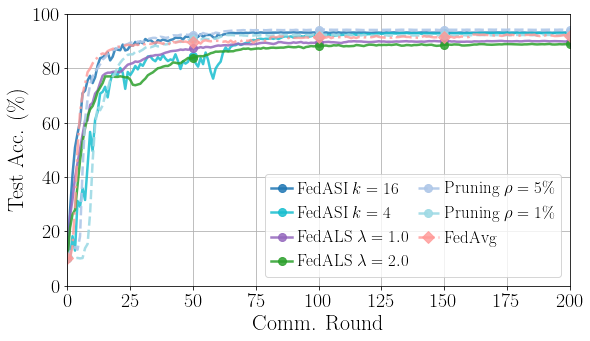

In [104]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

x = [i for i in range(0, 201)]

ax.plot(x, dr['16']['acc'], c=cm[0] , label='FedASI $k=16$', **st)
ax.plot(x, dr['4']['acc'] , c=cm[18], label='FedASI $k=4$' , **st)

ax.plot(x, dr['110']['acc'], c=cm[8] , label='FedALS $\\lambda=1.0$', **st)
ax.plot(x, dr['120']['acc'], c=cm[4] , label='FedALS $\\lambda=2.0$', **st)

ax.plot(x, dr['p16']['acc'], c=cm[1], label='Pruning $\\rho=5\%$', **sp)
ax.plot(x, dr['p4']['acc'], c=cm[19], label='Pruning $\\rho=1\%$', **sp)
ax.plot(x, dr['b']['acc'] , c=cm[7] , label='FedAvg', **sq)

ax.set(xlim=[0, 200], ylim=[0, 100], 
       xlabel='Comm. Round', ylabel='Test Acc. (\%)')
ax.grid(True, axis='y')
ax.grid(True, which='both', axis='x')

ax.legend(ncol=2, loc=4, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5effper_accVrd_rsn.pdf', bbox_inches='tight')

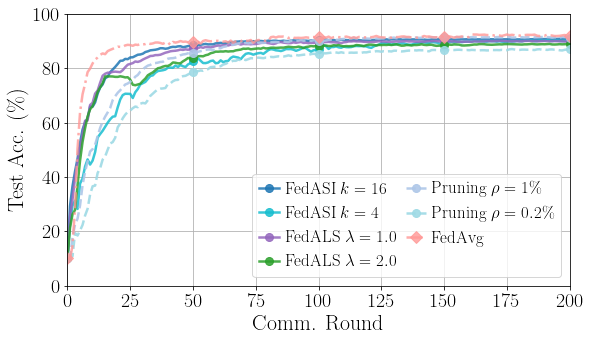

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

x = [i for i in range(0, 201)]

ax.plot(x, dv['16']['acc'], c=cm[0] , label='FedASI $k=16$', **st)
ax.plot(x, dv['4']['acc'] , c=cm[18], label='FedASI $k=4$' , **st)

ax.plot(x, dv['110']['acc'], c=cm[8] , label='FedALS $\\lambda=1.0$', **st)
ax.plot(x, dv['120']['acc'], c=cm[4] , label='FedALS $\\lambda=2.0$', **st)

ax.plot(x, dv['p16']['acc'], c=cm[1], label='Pruning $\\rho=1\%$', **sp)
ax.plot(x, dv['p4']['acc'], c=cm[19], label='Pruning $\\rho=0.2\%$', **sp)
ax.plot(x, dv['b']['acc'] , c=cm[7] , label='FedAvg', **sq)

ax.set(xlim=[0, 200], ylim=[0, 100], 
       xlabel='Comm. Round', ylabel='Test Acc. (\%)')
ax.grid(True, axis='y')
ax.grid(True, which='both', axis='x')

ax.legend(ncol=2, loc=4, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5effper_accVrd_vgg.pdf', bbox_inches='tight')

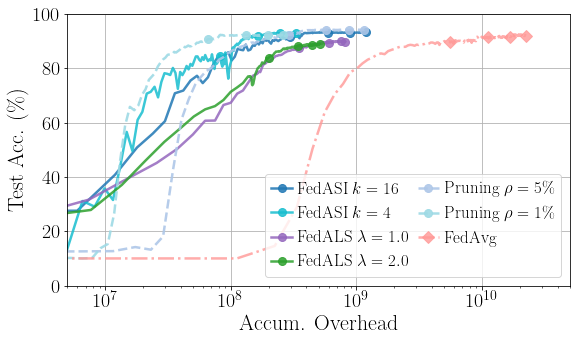

In [105]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

ax.semilogx(dr['16']['comm'], dr['16']['acc'], c=cm[0] , label='FedASI $k=16$', **st)
ax.semilogx(dr['4']['comm'] , dr['4']['acc'] , c=cm[18], label='FedASI $k=4$' , **st)

ax.semilogx(dr['110']['comm'], dr['110']['acc'], c=cm[8], label='FedALS $\\lambda=1.0$', **st)
ax.semilogx(dr['120']['comm'], dr['120']['acc'], c=cm[4], label='FedALS $\\lambda=2.0$' , **st)

ax.semilogx(dr['p16']['comm'], dr['p16']['acc'], c=cm[1], label='Pruning $\\rho=5\%$', **sp)
ax.semilogx(dr['p4']['comm'], dr['p4']['acc'], c=cm[19], label='Pruning $\\rho=1\%$' , **sp)
ax.semilogx(dr['b']['comm'] , dr['b']['acc'] , c=cm[7] , label='FedAvg', **sq)

ax.set(xlim=[5e6, 5e10], ylim=[0, 100], 
       xlabel='Accum. Overhead', ylabel='Test Acc. (\%)')
ax.grid(True, axis='y')
ax.grid(True, which='major', axis='x')

ax.legend(ncol=2, loc=4, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5effper_accVoh_rsn.pdf', bbox_inches='tight')

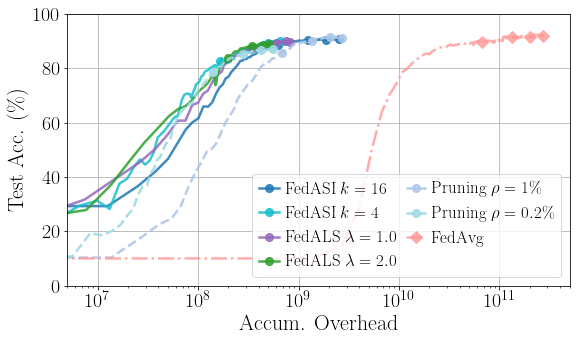

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

ax.semilogx(dv['16']['comm'], dv['16']['acc'], c=cm[0] , label='FedASI $k=16$', **st)
ax.semilogx(dv['4']['comm'] , dv['4']['acc'] , c=cm[18], label='FedASI $k=4$' , **st)

ax.semilogx(dv['110']['comm'], dv['110']['acc'], c=cm[8], label='FedALS $\\lambda=1.0$', **st)
ax.semilogx(dv['120']['comm'], dv['120']['acc'], c=cm[4], label='FedALS $\\lambda=2.0$' , **st)

ax.semilogx(dv['p16']['comm'], dv['p16']['acc'], c=cm[1], label='Pruning $\\rho=1\%$', **sp)
ax.semilogx(dv['p4']['comm'] , dv['p4']['acc'], c=cm[19], label='Pruning $\\rho=0.2\%$' , **sp)
ax.semilogx(dv['b']['comm'] , dv['b']['acc'] , c=cm[7] , label='FedAvg', **sq)

ax.set(xlim=[5e6, 5e11], ylim=[0, 100], 
       xlabel='Accum. Overhead', ylabel='Test Acc. (\%)')
ax.grid(True, axis='y')
ax.grid(True, which='major', axis='x')

ax.legend(ncol=2, loc=4, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5effper_accVoh_vgg.pdf', bbox_inches='tight')

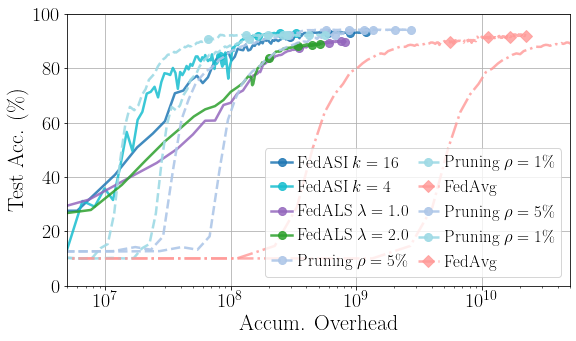

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

ax.semilogx(dr['16']['comm'], dr['16']['acc'], c=cm[0] , label='FedASI $k=16$', **st)
ax.semilogx(dr['4']['comm'] , dr['4']['acc'] , c=cm[18], label='FedASI $k=4$' , **st)

ax.semilogx(dr['110']['comm'], dr['110']['acc'], c=cm[8], label='FedALS $\\lambda=1.0$', **st)
ax.semilogx(dr['120']['comm'], dr['120']['acc'], c=cm[4], label='FedALS $\\lambda=2.0$' , **st)

ax.semilogx(dr['p16']['comm'], dr['p16']['acc'], c=cm[1], label='Pruning $\\rho=5\%$', **sp)
ax.semilogx(dr['p4']['comm'], dr['p4']['acc'], c=cm[19], label='Pruning $\\rho=1\%$' , **sp)
ax.semilogx(dr['b']['comm'] , dr['b']['acc'] , c=cm[7] , label='FedAvg', **sq)

ax.semilogx(dv['p16']['comm'], dr['p16']['acc'], c=cm[1], label='Pruning $\\rho=5\%$', **sp)
ax.semilogx(dv['p4']['comm'], dr['p4']['acc'], c=cm[19], label='Pruning $\\rho=1\%$' , **sp)
ax.semilogx(dv['b']['comm'] , dr['b']['acc'] , c=cm[7] , label='FedAvg', **sq)

ax.set(xlim=[5e6, 5e10], ylim=[0, 100], 
       xlabel='Accum. Overhead', ylabel='Test Acc. (\%)')
ax.grid(True, axis='y')
ax.grid(True, which='major', axis='x')

ax.legend(ncol=2, loc=4, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5effper_accVoh_vgg.pdf', bbox_inches='tight')

## FEMNIST

In [15]:
dr = {}
drr = 'PowerAvg'
flst = ['0630-01010d', '0630-c69bd2']
nlst = ['16', '4',]
for f, n in zip(flst, nlst):
    dr[n] = get_onef(drr, f, epc=100)
    
drr = 'PruneAvg'
flst = ['0729-b826f5', '0729-c8a431']
nlst = ['p16', 'p4' ]  # 2%, 0.5%
for f, n in zip(flst, nlst):
    dr[n] = get_onef(drr, f, epc=100)

drr = 'AlsAvg'
flst = ['0716-9faac9', '0716-3dc46e'] 
nlst = ['110', '120',] 
for f, n in zip(flst, nlst):
    dr[n] = get_onef(drr, f, epc=100)

dr['b'] = get_oneb('FedAvg', '0622-e67d6c', siz=6.4972e6, epc=100)

Warning AlsAvg 0716-9faac9 200
Warning AlsAvg 0716-3dc46e 200


In [16]:
cm = plt.cm.tab20(np.arange(0, 20))
st = {'ls': '-',  'lw': 2.5, 'marker': 'o', 'ms': 8, 'markevery': 25, 'alpha': 0.85}
sp = {'ls': '--', 'lw': 2.5, 'marker': 'o', 'ms': 8, 'markevery': 25, 'alpha': 0.9}
sq = {'ls': '-.', 'lw': 2.5, 'marker': 'D', 'ms': 8, 'markevery': 25, 'alpha': 0.8}

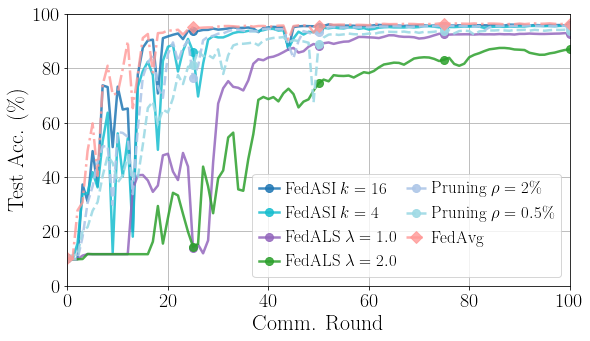

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

x = [i for i in range(0, 101)]

ax.plot(x, dr['16']['acc'], c=cm[0] , label='FedASI $k=16$', **st)
ax.plot(x, dr['4']['acc'] , c=cm[18], label='FedASI $k=4$' , **st)

ax.plot(x, dr['110']['acc'], c=cm[8] , label='FedALS $\\lambda=1.0$', **st)
ax.plot(x, dr['120']['acc'], c=cm[4] , label='FedALS $\\lambda=2.0$', **st)

ax.plot(x, dr['p16']['acc'], c=cm[1], label='Pruning $\\rho=2\%$', **sp)
ax.plot(x, dr['p4']['acc'], c=cm[19], label='Pruning $\\rho=0.5\%$', **sp)
ax.plot(x, dr['b']['acc'] , c=cm[7] , label='FedAvg', **sq)

ax.set(xlim=[0, 100], ylim=[0, 100], 
       xlabel='Comm. Round', ylabel='Test Acc. (\%)')
ax.grid(True, axis='y')
ax.grid(True, which='both', axis='x')

ax.legend(ncol=2, loc=4, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5effper_accVrd_cnn.pdf', bbox_inches='tight')

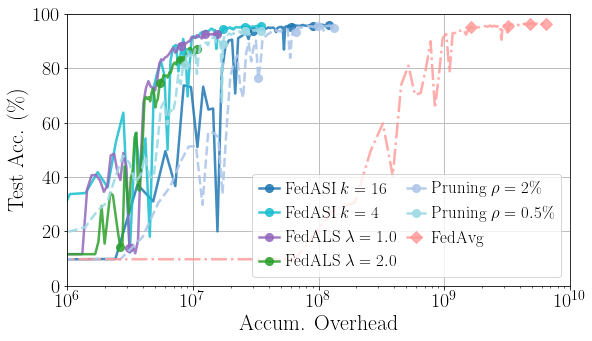

In [108]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

ax.semilogx(dr['16']['comm'], dr['16']['acc'], c=cm[0] , label='FedASI $k=16$', **st)
ax.semilogx(dr['4']['comm'] , dr['4']['acc'] , c=cm[18], label='FedASI $k=4$' , **st)

ax.semilogx(dr['110']['comm'], dr['110']['acc'], c=cm[8], label='FedALS $\\lambda=1.0$', **st)
ax.semilogx(dr['120']['comm'], dr['120']['acc'], c=cm[4], label='FedALS $\\lambda=2.0$' , **st)

ax.semilogx(dr['p16']['comm'], dr['p16']['acc'], c=cm[1], label='Pruning $\\rho=2\%$', **sp)
ax.semilogx(dr['p4']['comm'], dr['p4']['acc'], c=cm[19], label='Pruning $\\rho=0.5\%$' , **sp)
ax.semilogx(dr['b']['comm'] , dr['b']['acc'] , c=cm[7] , label='FedAvg', **sq)

ax.set(xlim=[1e6, 1e10], ylim=[0, 100], 
       xlabel='Accum. Overhead', ylabel='Test Acc. (\%)')
ax.grid(True, axis='y')
ax.grid(True, which='major', axis='x')

ax.legend(ncol=2, loc=4, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5effper_accVoh_cnn.pdf', bbox_inches='tight')

## Shakespeare

In [48]:
dr = {}
drr = 'PowerAvg'
flst = ['0729-878c3f', '0729-4df1bb']
nlst = ['16', '4',]
for f, n in zip(flst, nlst):
    dr[n] = get_onef(drr, f, epc=100)
    
# drr = 'PruneAvg'
# flst = ['0729-b826f5', '0729-c8a431']
# nlst = ['p16', 'p4' ]  # 2%, 0.5%
# for f, n in zip(flst, nlst):
#     dr[n] = get_onef(drr, f, epc=100)

drr = 'AlsAvg'
flst = ['0729-10a573', '0729-afa7a4'] 
nlst = ['110', '120',] 
for f, n in zip(flst, nlst):
    dr[n] = get_onef(drr, f, epc=100)

dr['b'] = get_oneb('FedAvg', '0706-3c756a', siz=6.4972e6, epc=100)

In [49]:
cm = plt.cm.tab20(np.arange(0, 20))
st = {'ls': '-',  'lw': 2.5, 'marker': 'o', 'ms': 8, 'markevery': 5, 'alpha': 0.85}
sp = {'ls': '--', 'lw': 2.5, 'marker': 'o', 'ms': 8, 'markevery': 5, 'alpha': 0.9}
sq = {'ls': '-.', 'lw': 2.5, 'marker': 'D', 'ms': 8, 'markevery': 5, 'alpha': 0.8}

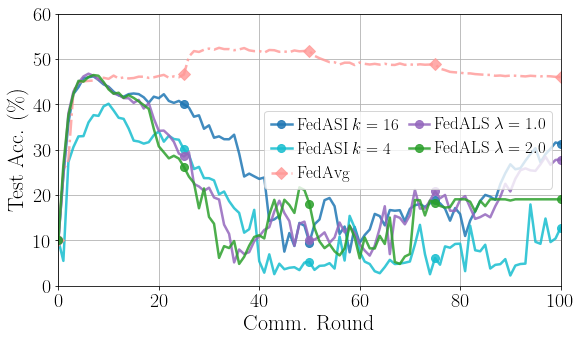

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

x = [i for i in range(0, 101)]

ax.plot(x, dr['16']['acc'], c=cm[0] , label='FedASI $k=16$', **st)
ax.plot(x, dr['4']['acc'] , c=cm[18], label='FedASI $k=4$' , **st)
ax.plot(x, dr['b']['acc'] , c=cm[7] , label='FedAvg', **sq)

ax.plot(x, dr['110']['acc'], c=cm[8] , label='FedALS $\\lambda=1.0$', **st)
ax.plot(x, dr['120']['acc'], c=cm[4] , label='FedALS $\\lambda=2.0$', **st)

# ax.plot(x, dr['p16']['acc'], c=cm[1], label='Pruning $\\rho=5\%$', **sp)
# ax.plot(x, dr['p4']['acc'], c=cm[19], label='Pruning $\\rho=1\%$', **sp)

ax.set(xlim=[0, 100], ylim=[0, 60], 
       xlabel='Comm. Round', ylabel='Test Acc. (\%)')
ax.grid(True, axis='y')
ax.grid(True, which='both', axis='x')

ax.legend(ncol=2, loc=7, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5effper_accVrd_lstm.pdf', bbox_inches='tight')

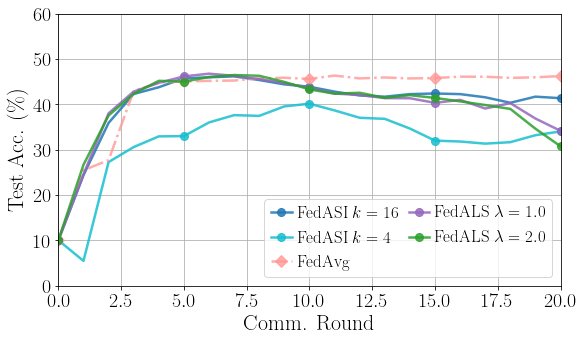

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

x = [i for i in range(0, 101)]

ax.plot(x, dr['16']['acc'], c=cm[0] , label='FedASI $k=16$', **st)
ax.plot(x, dr['4']['acc'] , c=cm[18], label='FedASI $k=4$' , **st)
ax.plot(x, dr['b']['acc'] , c=cm[7] , label='FedAvg', **sq)

ax.plot(x, dr['110']['acc'], c=cm[8] , label='FedALS $\\lambda=1.0$', **st)
ax.plot(x, dr['120']['acc'], c=cm[4] , label='FedALS $\\lambda=2.0$', **st)

# ax.plot(x, dr['p16']['acc'], c=cm[1], label='Pruning $\\rho=5\%$', **sp)
# ax.plot(x, dr['p4']['acc'], c=cm[19], label='Pruning $\\rho=1\%$', **sp)

ax.set(xlim=[0, 20], ylim=[0, 60], 
       xlabel='Comm. Round', ylabel='Test Acc. (\%)')
ax.grid(True, axis='y')
ax.grid(True, which='both', axis='x')

ax.legend(ncol=2, loc=4, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5effper_accVrd_lstm.pdf', bbox_inches='tight')

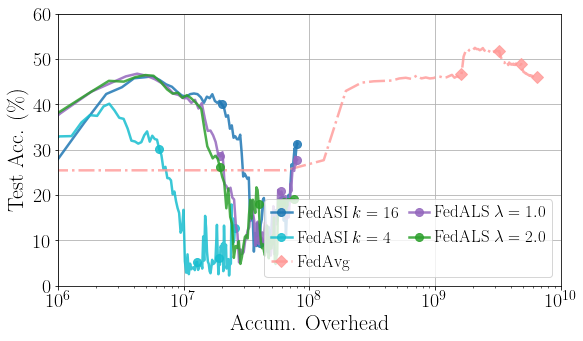

In [122]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

ax.semilogx(dr['16']['comm'], dr['16']['acc'], c=cm[0] , label='FedASI $k=16$', **st)
ax.semilogx(dr['4']['comm'] , dr['4']['acc'] , c=cm[18], label='FedASI $k=4$' , **st)

# ax.semilogx(dr['p16']['comm'], dr['p16']['acc'], c=cm[1], label='Pruning $\\rho=2\%$', **sp)
# ax.semilogx(dr['p4']['comm'], dr['p4']['acc'], c=cm[19], label='Pruning $\\rho=0.5\%$' , **sp)
ax.semilogx(dr['b']['comm'] , dr['b']['acc'] , c=cm[7] , label='FedAvg', **sq)

ax.semilogx(dr['110']['comm'], dr['110']['acc'], c=cm[8], label='FedALS $\\lambda=1.0$', **st)
ax.semilogx(dr['120']['comm'], dr['120']['acc'], c=cm[4], label='FedALS $\\lambda=2.0$' , **st)

ax.set(xlim=[1e6, 1e10], ylim=[0, 60], 
       xlabel='Accum. Overhead', ylabel='Test Acc. (\%)')
ax.grid(True, axis='y')
ax.grid(True, which='major', axis='x')

ax.legend(ncol=2, loc=4, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5effper_accVoh_lstm.pdf', bbox_inches='tight')

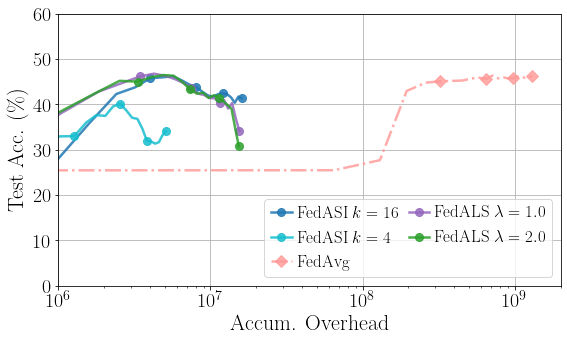

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

ax.semilogx(dr['16']['comm'][:21], dr['16']['acc'][:21], c=cm[0] , label='FedASI $k=16$', **st)
ax.semilogx(dr['4']['comm'][:21] , dr['4']['acc'][:21] , c=cm[18], label='FedASI $k=4$' , **st)

# ax.semilogx(dr['p16']['comm'], dr['p16']['acc'], c=cm[1], label='Pruning $\\rho=2\%$', **sp)
# ax.semilogx(dr['p4']['comm'], dr['p4']['acc'], c=cm[19], label='Pruning $\\rho=0.5\%$' , **sp)
ax.semilogx(dr['b']['comm'][:21] , dr['b']['acc'][:21] , c=cm[7] , label='FedAvg', **sq)

ax.semilogx(dr['110']['comm'][:21], dr['110']['acc'][:21], c=cm[8], label='FedALS $\\lambda=1.0$', **st)
ax.semilogx(dr['120']['comm'][:21], dr['120']['acc'][:21], c=cm[4], label='FedALS $\\lambda=2.0$' , **st)

ax.set(xlim=[1e6, 2e9], ylim=[0, 60], 
       xlabel='Accum. Overhead', ylabel='Test Acc. (\%)')
ax.grid(True, axis='y')
ax.grid(True, which='major', axis='x')

ax.legend(ncol=2, loc=4, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5effper_accVoh_lstm.pdf', bbox_inches='tight')